In [3]:
!pip install shap

   ---------------------------------------- 0.0/549.1 kB ? eta -:--:--
   ---------------------------------------- 549.1/549.1 kB 5.0 MB/s eta 0:00:00

   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   ---------------------------------------- 2/2 [shap]



 98%|===================| 8337/8520 [00:23<00:00]        

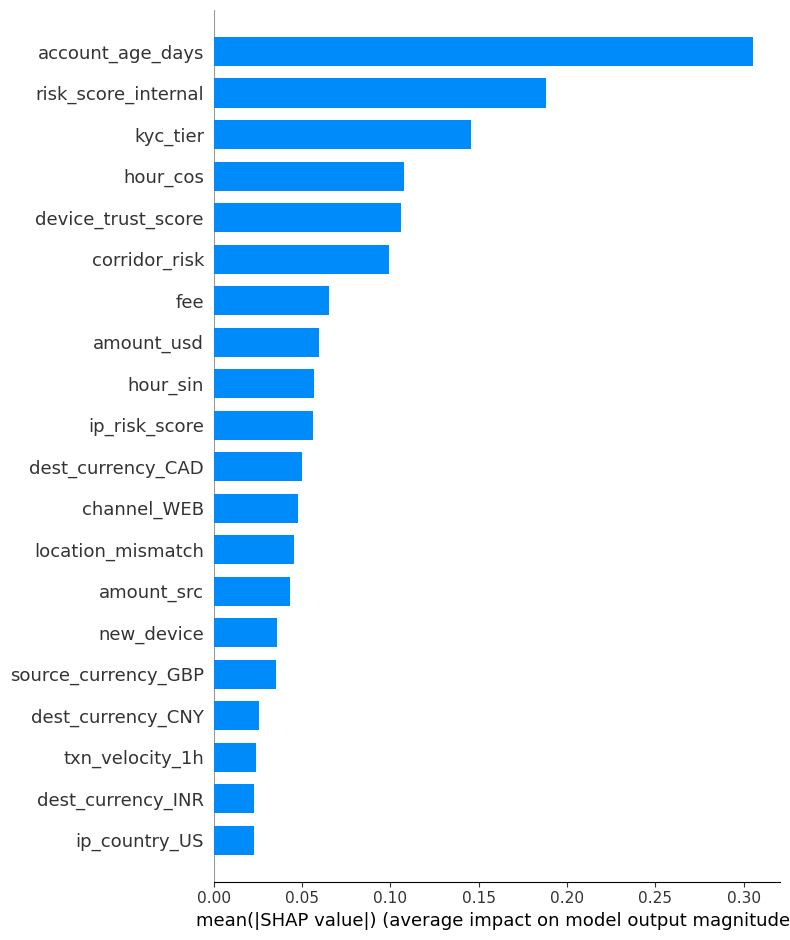

{'fraud_score': 0.0599, 'decision': 'ALLOW', 'reason_codes': []}


In [14]:
import numpy as np
import pandas as pd
import joblib
import shap
from sklearn.model_selection import train_test_split

# ======================
# Load Model & Data
# ======================
model_lgb = joblib.load("../artifacts/model/fraud_model.pkl")
df = pd.read_csv("../output/preprocessed_data.csv")

TARGET = "is_fraud"

FEATURE_NAMES = [c for c in df.columns if c != TARGET]

X = df[FEATURE_NAMES]

y = df[TARGET]

# ======================
# Train/Test split
# ======================
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

X_train_np = X_train.values.astype(np.float32)
X_test_np = X_test.values.astype(np.float32)

# ======================
# SHAP background
# ======================
X_background = X_train_np[np.random.choice(len(X_train_np), min(300, len(X_train_np)), replace=False)]

explainer = shap.TreeExplainer(model_lgb, X_background, feature_perturbation="interventional")

# ======================
# SHAP summary (global)
# ======================
shap_values_all = explainer(X_train_np, check_additivity=False).values

shap.summary_plot(shap_values_all, X_train_np, feature_names=FEATURE_NAMES, plot_type="bar")

# ======================
# Single prediction + reasons
# ======================
fraud_score = model_lgb.predict_proba(X_test_np[:1])[0, 1]

decision = "ALLOW"
if fraud_score > 0.6:
    decision = "BLOCK"
elif fraud_score > 0.5:
    decision = "STEP_UP"

REASON_MAP = {
    "new_device": "New or untrusted device",
    "ip_risk_score": "High-risk IP",
    "location_mismatch": "Unusual location",
    "txn_velocity_1h": "High transaction frequency",
    "amount_usd": "Unusual transaction amount",
}

reasons = []

if decision != "ALLOW":
    shap_values = explainer(X_test_np[:1], check_additivity=False)
    shap_vals = shap_values.values[0]

    top_idx = np.argsort(np.abs(shap_vals))[-3:]
    reasons = [
        REASON_MAP.get(FEATURE_NAMES[i], FEATURE_NAMES[i])
        for i in reversed(top_idx)
    ]

result = {
    "fraud_score": round(float(fraud_score), 4),
    "decision": decision,
    "reason_codes": reasons
}

print(result)
